# ST1510 PDAS CA2 — Job Analytics: Field-of-Study Career Value

**Group:** _<fill in class + names + student IDs>_

## Research Question

> **Which field of study offers the best long-term career value for Singapore graduates when starting salary, employment stability, and career growth trends conflict?**

This question requires synthesising **multiple, sometimes conflicting** indicators — starting pay, pay stability/predictability, long-run salary growth, automation risk, and job satisfaction — into a single justified conclusion, rather than ranking fields on one metric alone.

## Datasets Used (group-wide — 4 total)

| # | Dataset | Source | Role in analysis | Owner |
|---|---------|--------|-------------------|-------|
| 1 | Singapore Graduate Employment Survey (combined) | BrightSpace CA2 Datasets (SkillsFuture/MOE, originally [data.gov.sg](https://data.gov.sg)) | Real Singapore salary + employment-rate ("stability") data by university/school/degree, 2012–2022 | **this notebook** |
| 2 | Job Salary Prediction Dataset | [Kaggle: nalisha/job-salary-prediction-dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset) | Salary trajectory by experience/education level (growth axis) | teammate |
| 3 | AI-Powered Job Market Insights | [Kaggle: uom190346a/ai-powered-job-market-insights](https://www.kaggle.com/datasets/uom190346a/ai-powered-job-market-insights) | Automation risk & job growth projection by industry (stability/risk axis) | teammate |
| 4 | HR Employee Dataset | [Kaggle: justinlimyin/hr-employee-dataset](https://www.kaggle.com/datasets/justinlimyin/hr-employee-dataset) | Job satisfaction & work-life balance by department (the "meaning/culture" axis) | teammate |

Per the assignment brief, **datasets are not force-merged** together — each is cleaned and analysed on its own terms, and the four perspectives are synthesised qualitatively in the Insights/Conclusion section to answer the research question.

> **Note:** this notebook currently covers **Dataset 1 only** (the required BrightSpace dataset) — that's this group member's assigned part. Teammates will add Datasets 2–4 and the remaining 4 visualizations (KDE, Pairplot, + 2 free choice) in their own sections before the notebook is combined for submission.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Dataset 1 — Singapore Graduate Employment Survey (combined)

**Required dataset** — derived from combining the two BrightSpace sub-datasets on their shared `Key` column:
- `ges_part1_ids.csv` — `year, university, school, degree, Key`
- `ges_part2_metrics.csv` — employment rates + salary metrics, `Key` (plus duplicate/blank columns to be dropped)


In [2]:
ids = pd.read_csv("../data/ges_part1_ids.csv")
metrics = pd.read_csv("../data/ges_part2_metrics.csv")

# metrics.csv repeats the 4 gross_monthly_* columns a second time and has many blank/unnamed columns.
# pandas renames the repeats with a ".1" suffix on read (rather than flagging them as literal
# duplicate names), so we drop by suffix/prefix instead of relying on columns.duplicated().
metrics = metrics.loc[:, ~metrics.columns.str.endswith(".1")]
metrics = metrics.loc[:, ~metrics.columns.str.startswith("Unnamed")]

ges = ids.merge(metrics, on="Key", how="inner").drop(columns=["Key"])
print(ids.shape, metrics.shape, "->", ges.shape)
ges.head()


(5135, 5) (5135, 9) -> (5135, 12)


,year,university,school,degree,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,97.4,96.1,3701,3200,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),97.1,95.7,2850,2700,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),90.9,85.7,3053,3000,3214,3000,2700,3500
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,87.5,87.5,3557,3400,3615,3400,3000,4100
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,95.3,95.3,3494,3500,3536,3500,3100,3816


In [3]:
numeric_cols = [
    "employment_rate_overall", "employment_rate_ft_perm",
    "basic_monthly_mean", "basic_monthly_median",
    "gross_monthly_mean", "gross_monthly_median",
    "gross_mthly_25_percentile", "gross_mthly_75_percentile",
]

for c in numeric_cols:
    ges[c] = pd.to_numeric(ges[c], errors="coerce")  # "na" strings -> NaN

ges["university"] = ges["university"].astype(str).str.strip()
ges["school"] = ges["school"].astype(str).str.strip()
ges["degree"] = ges["degree"].astype(str).str.strip()

before = len(ges)
ges_clean = ges.dropna(subset=["employment_rate_overall", "basic_monthly_median"]).copy()
print(f"Dropped {before - len(ges_clean)} rows with missing employment/salary data (kept {len(ges_clean)})")

ges_clean.to_csv("../data/ges_combined_clean.csv", index=False)
ges_clean.describe(include="number")


Dropped 479 rows with missing employment/salary data (kept 4656)


,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
count,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000
mean,91.761662,81.954639,3617.053836,3492.168363,3732.680436,3584.053316,3254.724463,4041.400911
std,6.524101,14.536497,799.943893,747.767382,825.160580,780.663890,669.538439,961.207428
min,66.700000,14.300000,263.900000,250.000000,263.800000,250.000000,230.000000,290.000000
25%,88.000000,74.200000,3213.000000,3100.000000,3321.000000,3200.000000,3000.000000,3500.000000
50%,93.000000,85.500000,3504.000000,3400.000000,3616.000000,3500.000000,3200.000000,3900.000000
75%,97.000000,93.000000,3980.250000,3800.000000,4088.250000,3900.000000,3500.000000,4500.000000
max,100.000000,100.000000,6962.000000,6500.000000,7139.000000,6600.000000,6000.000000,9967.000000


**Cleaning steps applied:** joined on `Key`; dropped duplicate/blank columns from the metrics file; coerced salary & employment-rate columns to numeric (the source encodes missing values as the string `"na"`, which becomes `NaN`); trimmed whitespace on text columns; dropped rows with no employment-rate or salary data (too incomplete to use). Saved the cleaned, combined dataset to `data/ges_combined_clean.csv` — **this is the required "combined BrightSpace dataset."**


## 2. Visualization — Box Plot (this notebook's contribution to the 5 required)

Group requirement: 5 visualizations total, at least one Box Plot, one KDE, one Pairplot, + 2 free choice. **This section supplies the Box Plot**, built from the GES dataset. Teammates will add the KDE, Pairplot, and 2 remaining charts from their datasets.


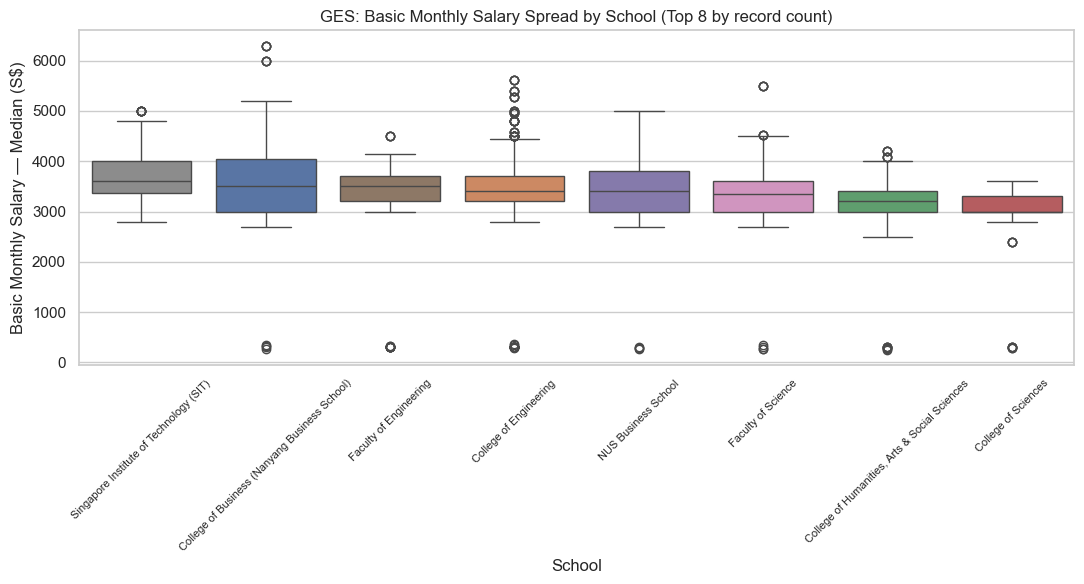

In [4]:
top_schools = ges_clean["school"].value_counts().head(8).index
subset = ges_clean[ges_clean["school"].isin(top_schools)]
order = subset.groupby("school")["basic_monthly_median"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=subset, x="school", y="basic_monthly_median", order=order, hue="school", legend=False, ax=ax)
ax.set_title("GES: Basic Monthly Salary Spread by School (Top 8 by record count)")
ax.set_xlabel("School")
ax.set_ylabel("Basic Monthly Salary — Median (S$)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
fig.tight_layout()
plt.show()


## 3. Insights — GES dataset (this section only)

_Fill in after running the analysis above:_

- **GES (Singapore reality check):** which schools/degrees combine high salary **and** high employment stability vs. those trading one for the other?

> The full Insights & Synthesis section (combining all 4 datasets to answer the research question) belongs in the group's final combined notebook, once Datasets 2–4 are merged in by teammates.
